In [1]:
import torch
from transformers import pipeline
from youtube_transcript_api import YouTubeTranscriptApi




/opt/anaconda3/envs/yt_analyzer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from youtube_transcript_api import YouTubeTranscriptApi

video_id = "LIb4fdwq7UM"  # replace with any video
#https://www.youtube.com/watch?v=LIb4fdwq7UM

ytt_api = YouTubeTranscriptApi()
transcript = ytt_api.fetch(video_id)
print(transcript[:5])



[FetchedTranscriptSnippet(text="- If we don't challenge anymore,", start=0.33, duration=1.86), FetchedTranscriptSnippet(text="then I think there's no reason\nthat we should, you know,", start=2.19, duration=3.42), FetchedTranscriptSnippet(text='we should keep doing this as a team.', start=5.61, duration=2.82), FetchedTranscriptSnippet(text='So we have to show the world\nthat we are still ongoing', start=8.43, duration=4.32), FetchedTranscriptSnippet(text='and still exploring and,', start=12.75, duration=1.98)]


In [3]:
import pandas as pd

df = pd.DataFrame(transcript)
df.head()

,text,start,duration
0,"- If we don't challenge anymore,",0.33,1.86
1,then I think there's no reason\nthat we should...,2.19,3.42
2,we should keep doing this as a team.,5.61,2.82
3,So we have to show the world\nthat we are stil...,8.43,4.32
4,"and still exploring and,",12.75,1.98


In [4]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub('\n', ' ', text)
    return text
    

df['clean_text'] = df['text'].apply(clean_text)

In [5]:
df

,text,start,duration,clean_text
0,"- If we don't challenge anymore,",0.33,1.86,if we dont challenge anymore
1,then I think there's no reason\nthat we should...,2.19,3.42,then i think theres no reason that we should y...
2,we should keep doing this as a team.,5.61,2.82,we should keep doing this as a team
3,So we have to show the world\nthat we are stil...,8.43,4.32,so we have to show the world that we are still...
4,"and still exploring and,",12.75,1.98,and still exploring and
...,...,...,...,...
295,I think life is fun because\nit's not because ...,931.43,4.59,i think life is fun because its not because im...
296,"or I'm a, I'm a star in\nthe spotlight, I think,",936.02,4.05,or im a im a star in the spotlight i think
297,I think just life is fun\nand living is better.,941.27,4.80,i think just life is fun and living is better
298,- I thought we'd end with the\nmeaning of life...,946.07,2.10,i thought wed end with the meaning of life th...


In [6]:
chunk_size = 30  # seconds

df['chunk'] = (df['start'] // chunk_size).astype(int)

chunked = df.groupby('chunk').agg({
    'clean_text': ' '.join,
    'start': 'min'
}).reset_index()

chunked.head()

,chunk,clean_text,start
0,0,if we dont challenge anymore then i think the...,0.330
1,1,rm of bts welcome back to the cover of rollin...,34.335
2,2,that im im okay and im ready all decided every...,60.870
3,3,and forth every time every night i think like ...,93.270
4,4,but the funny thing is it was like exactly the...,120.690


In [8]:
from transformers import pipeline
sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment"
)

label_map = {
    "LABEL_0": "negative",
    "LABEL_1": "neutral",
    "LABEL_2": "positive"
}

texts = chunked['clean_text'].str.slice(0, 512).tolist()

results = sentiment_model(texts, batch_size=16)

chunked['sentiment'] = [label_map[r['label']] for r in results]

print(chunked.head())

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 38743.34it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   chunk                                         clean_text    start sentiment
0      0   if we dont challenge anymore then i think the...    0.330   neutral
1      1   rm of bts welcome back to the cover of rollin...   34.335  positive
2      2  that im im okay and im ready all decided every...   60.870  positive
3      3  and forth every time every night i think like ...   93.270   neutral
4      4  but the funny thing is it was like exactly the...  120.690  positive


In [9]:
from keybert import KeyBERT

kw_model = KeyBERT()

def extract_topic(text):
    keywords = kw_model.extract_keywords(text, top_n=1)
    return keywords[0][0] if keywords else None

chunked['topic'] = chunked['clean_text'].apply(extract_topic)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14246.11it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
chunked

,chunk,clean_text,start,sentiment,topic
0,0,if we dont challenge anymore then i think the...,0.330,neutral,challenge
1,1,rm of bts welcome back to the cover of rollin...,34.335,positive,bts
2,2,that im im okay and im ready all decided every...,60.870,positive,fears
3,3,and forth every time every night i think like ...,93.270,neutral,depressed
4,4,but the funny thing is it was like exactly the...,120.690,positive,pharrell
5,5,did you come back around and how was that jour...,151.110,positive,music
6,6,and more kind of like intellectual things in t...,180.670,positive,listening
7,7,solan it was like tzo singing yes the phrase...,213.915,neutral,singing
8,8,so it and and like di deons album was was grea...,240.010,positive,spotify
9,9,when it is combined with like certain type of ...,271.510,neutral,dance


In [11]:
def attention_score(text):
    words = text.split()
    unique_words = set(words)
    
    if len(words) == 0:
        return 0
    
    return len(unique_words) / len(words)

chunked['attention'] = chunked['clean_text'].apply(attention_score)

In [13]:
sentiment_score_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

chunked['sentiment_score'] = chunked['sentiment'].map(sentiment_score_map)

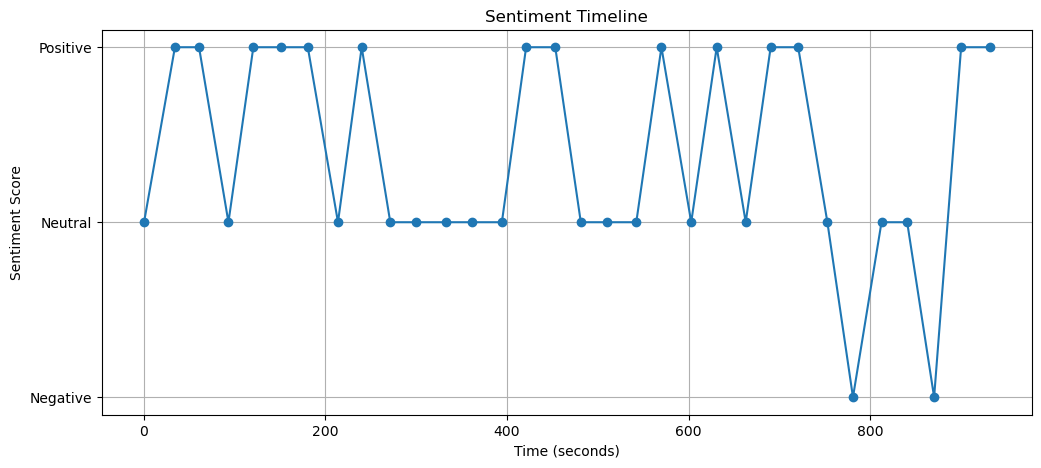

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(chunked['start'], chunked['sentiment_score'], marker='o')

plt.title("Sentiment Timeline")
plt.xlabel("Time (seconds)")
plt.ylabel("Sentiment Score")

plt.yticks([-1, 0, 1], ["Negative", "Neutral", "Positive"])

plt.grid()

plt.show()

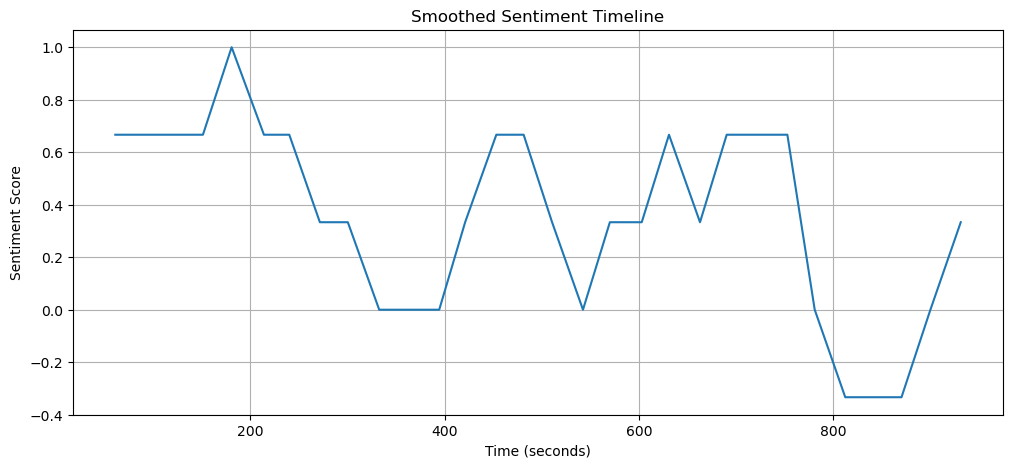

In [15]:
chunked['smooth_sentiment'] = chunked['sentiment_score'].rolling(window=3).mean()

plt.figure(figsize=(12, 5))
plt.plot(chunked['start'], chunked['smooth_sentiment'])

plt.title("Smoothed Sentiment Timeline")
plt.xlabel("Time (seconds)")
plt.ylabel("Sentiment Score")

plt.grid()
plt.show()

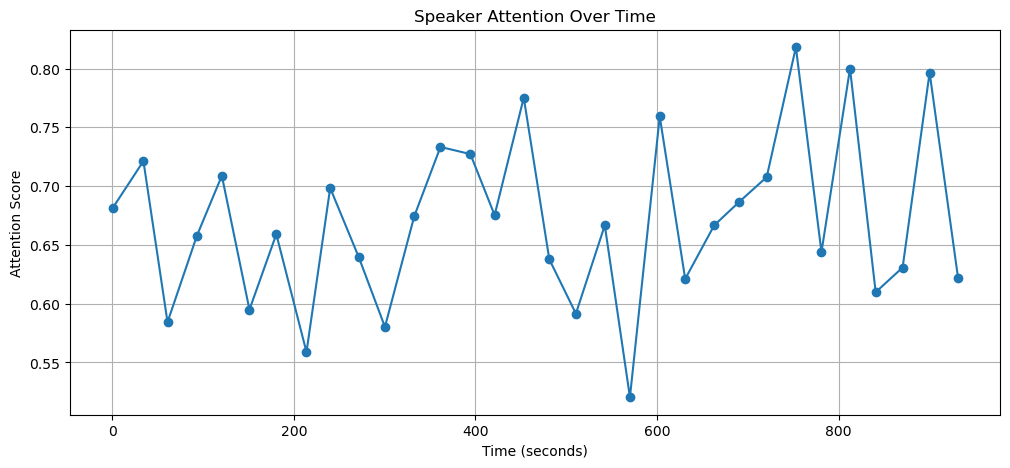

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(chunked['start'], chunked['attention'], marker='o')

plt.title("Speaker Attention Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Attention Score")

plt.grid()
plt.show()

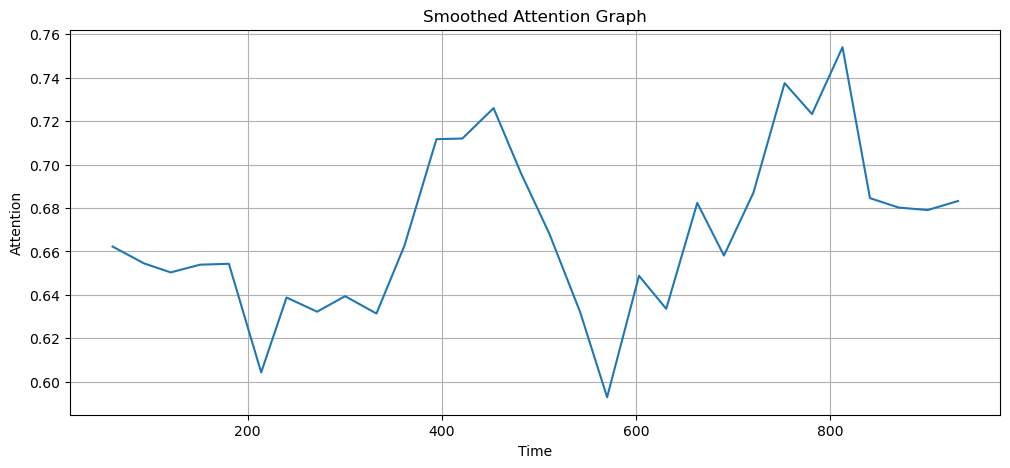

In [17]:
chunked['attention_smooth'] = chunked['attention'].rolling(window=3).mean()

plt.figure(figsize=(12, 5))
plt.plot(chunked['start'], chunked['attention_smooth'])

plt.title("Smoothed Attention Graph")
plt.xlabel("Time")
plt.ylabel("Attention")

plt.grid()
plt.show()

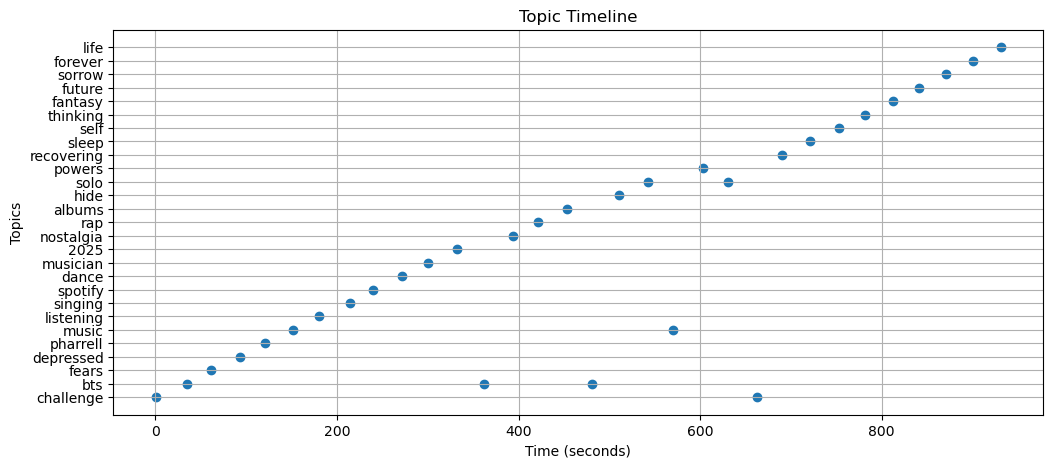

In [18]:
plt.figure(figsize=(12, 5))

# Convert topics to numeric labels
topic_codes = {topic: i for i, topic in enumerate(chunked['topic'].unique())}
chunked['topic_num'] = chunked['topic'].map(topic_codes)

plt.scatter(chunked['start'], chunked['topic_num'])

plt.title("Topic Timeline")
plt.xlabel("Time (seconds)")
plt.ylabel("Topics")

# Show topic labels
plt.yticks(list(topic_codes.values()), list(topic_codes.keys()))

plt.grid()
plt.show()